In [23]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE  # Thêm SMOTE để xử lý dữ liệu không cân bằng
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from pandas import DataFrame, concat
import warnings
warnings.filterwarnings('ignore')

In [24]:
# Hàm chuyển đổi chuỗi dữ liệu thành dạng học supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together
    agg = concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [25]:
# Đọc dữ liệu
df_pre = pd.read_csv(r'C:\Users\leduc\SGU\Nghiencuukhoahoc\DATA-20241004T011516Z-001\DATA\Merged_PM2.5_AQI_18_23.csv', sep=",", dtype=str)
df_pre = df_pre[['AQI Category', 'wd', 'ws', 'Rainfall', 'low_leaf', 'temp', 'uvb']]

In [26]:
# Mã hóa nhãn
label_encoder = LabelEncoder()
df_pre['AQI Category'] = label_encoder.fit_transform(df_pre['AQI Category'])

# Chuyển đổi sang float32
feature_columns = ['wd', 'ws', 'Rainfall', 'low_leaf', 'temp', 'uvb']
df_pre[feature_columns] = df_pre[feature_columns].astype('float32')

In [27]:
# Chuẩn hóa đặc trưng
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler.fit_transform(df_pre[feature_columns])
scaled = np.concatenate([df_pre[['AQI Category']].values, scaled_features], axis=1)

In [56]:
# Chuyển đổi thành dạng supervised learning
n_hours = 24
n_features = len(feature_columns) + 1
reframed = series_to_supervised(scaled, n_in=n_hours, n_out=1)

In [57]:
# Chia dữ liệu thành input (X) và output (y)
n_obs = n_hours * n_features
X = reframed.iloc[:, :n_obs].values
y = reframed.iloc[:, n_obs].values  # Nhãn tại thời điểm t

In [58]:
# Debug: Kiểm tra nhãn
print("Unique labels in y_train before split:", np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Debug: Kiểm tra sau khi chia
print("Unique labels in y_train after split:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))

Unique labels in y_train before split: [0. 1. 2. 3. 4.]
Unique labels in y_train after split: [0. 1. 2. 3. 4.]
Unique labels in y_test: [0. 1. 2. 3. 4.]


In [59]:
# Áp dụng SMOTE với k_neighbors=2 để tránh lỗi khi số mẫu nhỏ
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Debug: Kiểm tra sau SMOTE
print("Unique labels in y_train_resampled:", np.unique(y_train_resampled))

# Reshape dữ liệu
X_train_resampled = X_train_resampled.reshape((X_train_resampled.shape[0], n_hours, n_features))
X_test = X_test.reshape((X_test.shape[0], n_hours, n_features))

Unique labels in y_train_resampled: [0. 1. 2. 3. 4.]


In [60]:
# Số lớp
num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)
y_train_resampled_int = y_train_resampled.astype(int)

# Chuyển y_test về integer (nếu hiện đang one-hot)
y_test_int = np.argmax(y_test, axis=1) if y_test.ndim>1 else y_test.astype(int)


Number of classes: 5


In [61]:
# Tính class weights từ dữ liệu đã SMOTE (phù hợp khi dùng class_weight)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
y_train_resampled_int = y_train_resampled.astype(int)
class_labels = np.unique(y_train_resampled_int)
cw = compute_class_weight(class_weight='balanced', classes=class_labels, y=y_train_resampled_int)
class_weights = {int(label): float(weight) for label, weight in zip(class_labels, cw)}
print("Class weights (from resampled):", class_weights)

Class weights (from resampled): {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


In [62]:
# Cố định seed để kết quả lặp lại tốt hơn
import numpy as _np
import tensorflow as _tf
_np.random.seed(42)
_tf.random.set_seed(42)

In [63]:
# Định nghĩa model với sửa lỗi KerasTensor
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Dropout, Bidirectional, LSTM
from tensorflow.keras.models import Model

def create_cnn_lstm_model(input_shape, cnn_filters=(64, 32), lstm_units=100, dropout_rate=0.3):
    inputs = Input(shape=input_shape)
    
    x = Conv1D(filters=cnn_filters[0], kernel_size=3, padding='same', activation='relu')(inputs)
    x = Conv1D(filters=cnn_filters[1], kernel_size=3, padding='same', activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)  # 6 -> 3
    
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
    x = Dropout(dropout_rate)(x)
    
    # Attention sử dụng các layer Keras để tránh lỗi KerasTensor
    attn_scores = Dense(1, activation='tanh')(x)
    attn_weights = tf.keras.layers.Softmax(axis=1)(attn_scores)  # Sử dụng Softmax layer
    x_weighted = tf.keras.layers.Multiply()([x, attn_weights])    # Multiply layer
    context = tf.keras.layers.Lambda(lambda z: tf.reduce_sum(z, axis=1))(x_weighted)  # Lambda cho reduce_sum
    
    x = Dense(128, activation='relu')(context)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=inputs, outputs=outputs, name='CNN_BiLSTM_Attention')

In [64]:
# Tạo model
model = create_cnn_lstm_model(
    input_shape=(n_hours, n_features),
    cnn_filters=(64, 32),
    lstm_units=100,
    dropout_rate=0.3
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [65]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7)

In [66]:
# Huấn luyện model
history = model.fit(
    X_train_resampled, y_train_resampled_int,
    validation_data=(X_test, y_test_int),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
3216/3216 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - accuracy: 0.7775 - loss: 0.5553 - val_accuracy: 0.8754 - val_loss: 0.5022 - learning_rate: 0.0010
Epoch 2/100
3216/3216 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.8750 - loss: 0.3547 - val_accuracy: 0.8758 - val_loss: 0.4829 - learning_rate: 0.0010
Epoch 3/100
3216/3216 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.8764 - loss: 0.3451 - val_accuracy: 0.8740 - val_loss: 0.4899 - learning_rate: 0.0010
Epoch 4/100
3216/3216 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.8853 - loss: 0.3210 - val_accuracy: 0.8757 - val_loss: 0.4832 - learning_rate: 0.0010
Epoch 5/100
3216/3216 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.8891 - loss: 0.3038 - val_accuracy: 0.8657 - val_loss: 0.4855 - learning_rate: 0.0010
Epoch 6/100
3216/3216 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.8944 - loss: 0.2877 - val_accuracy: 0.8604 - val_loss: 0.5024 - learning_rate: 0.0010
Epoch 7/100
3216/3216 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step -

236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Shapes: X_test: (7522, 24, 7) y_true: (7522,) y_pred: (7522,)
Unique y_true counts: [1153 5145  316  907    1]
Unique y_pred counts: [1175 5107  319  919    2]
Classification Report:
                                precision    recall  f1-score   support

                          Good       0.81      0.83      0.82      1153
                      Moderate       0.93      0.92      0.92      5145
                     Unhealthy       0.76      0.76      0.76       316
Unhealthy for Sensitive Groups       0.72      0.73      0.73       907
                Very Unhealthy       0.00      0.00      0.00         1

                      accuracy                           0.88      7522
                     macro avg       0.64      0.65      0.65      7522
                  weighted avg       0.88      0.88      0.88      7522



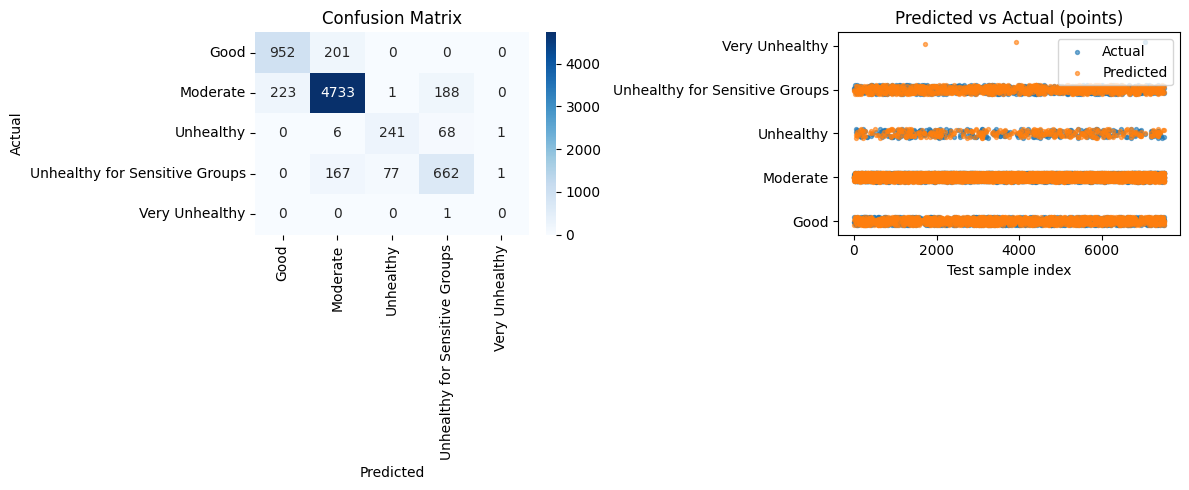

In [67]:
# ...existing code...
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy y_true nhất quán (ưu tiên y_test_int nếu có)
if 'y_test_int' in globals():
    y_true = y_test_int
elif 'y_test_classes' in globals():
    # convert one-hot -> int nếu cần
    y_true = np.argmax(y_test_classes, axis=1) if getattr(y_test_classes, 'ndim', 1) > 1 else y_test_classes
else:
    # fallback: try derive from y_test
    y_true = np.argmax(y_test, axis=1) if getattr(y_test, 'ndim', 1) > 1 else y_test

# y_pred_classes từ model.predict
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# In kiểm tra shape và một vài giá trị để debug
print("Shapes: X_test:", getattr(X_test, 'shape', None), "y_true:", y_true.shape, "y_pred:", y_pred_classes.shape)
print("Unique y_true counts:", np.bincount(y_true.astype(int)))
print("Unique y_pred counts:", np.bincount(y_pred_classes.astype(int)))

# Nếu mismatch về số mẫu, cắt xuống min để tránh lỗi
if y_pred_classes.shape[0] != y_true.shape[0]:
    n = min(y_pred_classes.shape[0], y_true.shape[0])
    print(f"Warning: length mismatch (pred={y_pred_classes.shape[0]}, true={y_true.shape[0]}). Trimming to {n}.")
    y_pred_classes = y_pred_classes[:n].astype(int)
    y_true = y_true[:n].astype(int)

# Classification report (sử dụng same y_true)
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_))

# Confusion matrix + scatter
cm = confusion_matrix(y_true, y_pred_classes, labels=np.arange(len(label_encoder.classes_)))
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')

plt.subplot(1,2,2)
idx = np.arange(len(y_true))
jitter = (np.random.RandomState(0).rand(len(idx)) - 0.5) * 0.2
plt.scatter(idx, y_true + jitter, s=8, c='C0', label='Actual', alpha=0.6)
plt.scatter(idx, y_pred_classes - jitter, s=8, c='C1', label='Predicted', alpha=0.6)
plt.yticks(np.arange(len(label_encoder.classes_)), label_encoder.classes_)
plt.xlabel('Test sample index'); plt.title('Predicted vs Actual (points)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'AQI_pred_vs_actual_timestep_{n_hours}_checked.png', dpi=200)
plt.show()

In [68]:
# Lưu kết quả với cột dự đoán và cột thực tế
# y_pred_classes đã có sẵn
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)

# Tìm biến nhãn test hợp lệ trong notebook (sử dụng thứ tự ưu tiên)
if 'y_test_classes' in globals():
    y_test_arr = y_test_classes
elif 'y_test_int' in globals():
    y_test_arr = y_test_int
elif 'y_true' in globals():
    y_test_arr = y_true
elif 'y_test' in globals():
    # nếu y_test là one-hot hoặc vector
    y_test_arr = np.argmax(y_test, axis=1) if getattr(y_test, 'ndim', 1) > 1 else y_test.astype(int)
else:
    raise NameError("Không tìm thấy biến nhãn test (y_test_classes, y_test_int, y_true hoặc y_test).")

# đảm bảo integer và đảo mã nhãn
y_test_arr = np.asarray(y_test_arr).astype(int)
y_test_labels = label_encoder.inverse_transform(y_test_arr)

output = pd.DataFrame({
    'Predicted_AQI_Category': y_pred_labels,
    'Actual_AQI_Category': y_test_labels
})
output.to_csv(f'CNN_LSTM_AQI_Classification_timestep_{n_hours}_optimized.csv', index=False)


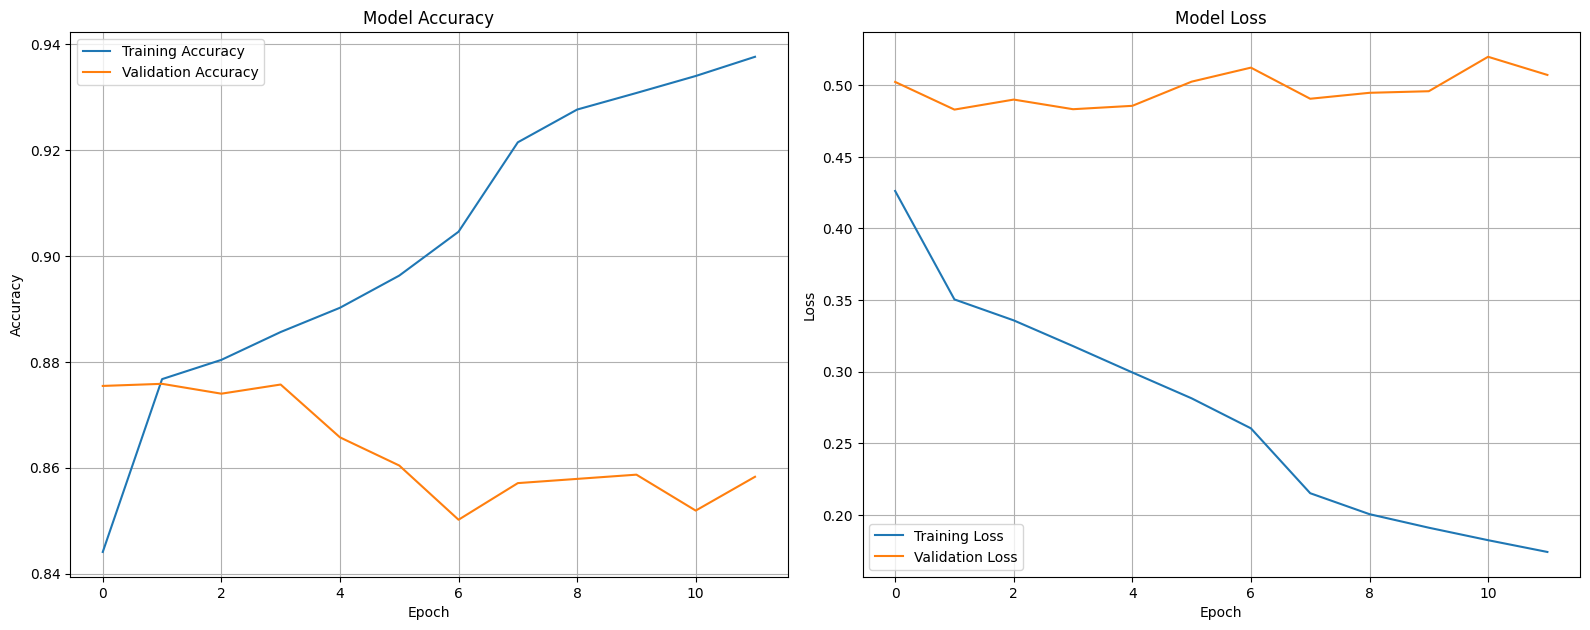

In [69]:
# Vẽ biểu đồ
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 12))
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()